## **Содержание**

### [Введение](#scrollTo=V55SPEgdqwpj)
### [Подготовка. Установка библиотек, подключение к Google Диску...](#scrollTo=Y8VbshAaehTV)

### Варианты векторизации
* [Вариант, где вектор — контент гигачанка](#scrollTo=aVvh5hSrTAh-)
* [Вариант, где вектор — это все вопросы кластера](#scrollTo=tmaf4Ja6XU9G)
* [Вариант, где вектор — это группа рандомная вопросов из кластера](#s#crollTo=jyN249MfTGfa)

### Подсчет статистики
* [Подсчет статистики чанков по преобладающему 50% кластеру среди 10 найденных](#scrollTo=v-GrtEUeAVGh)
* [Подсчет статистики чанков по преобладающему в принципе кластеру среди 10 найденных](#scrollTo=KFO54iAIKxvG)


## Введение

Этот ноутбук посвящен **оценке точности кластеризации**, которая была выполнена на предыдущем этапе. Он является второй частью исследования и фокусируется на проверке корректности работы алгоритмов кластеризации, анализе результатов и визуализации полученных данных.

Здесь предусмотрены:
- Загрузка промежуточных результатов кластеризации через чекпоинты.
- Оценка точности на основе различных критериев:
  - **50% попаданий** — кластер считается правильным, если более половины ближайших соседей принадлежат одному кластеру.
  - **Частотный кластер** — выбор наиболее часто встречающегося кластера среди ближайших соседей.
- Сравнение точности между разными подходами векторизации:
  - Векторизация на основе контента гигачанка.
  - Векторизация всех вопросов кластера.
  - Векторизация на основе случайных групп вопросов.
- Построение графиков и визуализация точности по кластерам.

Данная часть исследования помогает выявить сильные и слабые стороны кластеризации, оценить эффективность различных методов и определить направления для дальнейшего улучшения модели.

## **Примечание**

В документе предусмотрены блоки "**чекпоинт**". Они используются для загрузки результатов обработки данных, сохранённых на предыдущих этапах работы с ноутбуком. Это сделано для того, чтобы можно было продолжить с данного места, не производя все предыдущие вычисления повторно.

### **Выполнить перед началом работы**. Подготовка. Установка библиотек, подключение к Google Диску...

In [ ]:
!pip install -q langchain==0.3.23 langchain-community==0.3.21 langchain-core==0.3.55 langchain-openai==0.3.14 langchain-text-splitters==0.3.8 langsmith==0.3.31 openai==1.75.0 faiss-cpu==1.10.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 34.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 57.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 405.1/405.1 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 289.8/289.8 kB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.6/389.6 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.0/27.0 MB 40.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 36.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.3/49.3 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 146.1/146.1 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.4/128.4 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 454.3/454.3 kB 28.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.4

In [ ]:
# @title Импорты

import os
import copy
import re
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import json
from tqdm import tqdm_notebook as tqdm
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from google.colab import userdata
from langchain.text_splitter import (
    CharacterTextSplitter,
    NLTKTextSplitter,
    RecursiveCharacterTextSplitter,
)
from langchain.docstore.document import Document
from langchain.document_loaders import TextLoader
from langchain_openai import OpenAIEmbeddings
from langchain_community.vectorstores import FAISS
import openai
from openai import AsyncOpenAI, OpenAI
import tiktoken

warnings.filterwarnings("ignore")

In [ ]:
# @title Функция для загрузки данных из Яндекс.Диска в рабочий каталог **root_path**

import os
import requests
import zipfile
import shutil

def download_and_extract_yandex_disk(url, output_dir):
    """
    Скачивает архив с Яндекс.Диска и распаковывает содержимое корневой папки в указанный каталог.

    :param url: Ссылка на файл или папку на Яндекс.Диске (публичная).
    :param output_dir: Папка, куда будет распаковано содержимое архива.
    """
    os.makedirs(output_dir, exist_ok=True)
    zip_file_path = os.path.join(output_dir, 'data.zip')

    # Преобразование ссылки для прямого скачивания
    direct_url = f"https://cloud-api.yandex.net/v1/disk/public/resources/download?public_key={url}"
    response = requests.get(direct_url)
    if response.status_code != 200:
        print(f"Ошибка при запросе ссылки: {response.status_code}")
        return False

    download_link = response.json().get('href')
    if not download_link:
        print("Не удалось получить ссылку для скачивания.")
        return False

    # Скачиваем файл
    with requests.get(download_link, stream=True) as file_response:
        with open(zip_file_path, 'wb') as file:
            shutil.copyfileobj(file_response.raw, file)
    print(f"Файл успешно загружен: {zip_file_path}")

    # Распаковываем содержимое архива
    if zipfile.is_zipfile(zip_file_path):
        with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
            for member in zip_ref.namelist():
                # Извлекаем только файлы без корневой папки
                member_path = os.path.relpath(member, start=os.path.commonpath(zip_ref.namelist()))
                target_path = os.path.join(output_dir, member_path)
                if not member.endswith('/'):  # Пропускаем директории
                    os.makedirs(os.path.dirname(target_path), exist_ok=True)
                    with open(target_path, 'wb') as f:
                        f.write(zip_ref.read(member))
        print(f"Файлы успешно распакованы в папку: {output_dir}")
        os.remove(zip_file_path)  # Удаляем архив после распаковки
        return True
    else:
        print("Скачанный файл не является ZIP-архивом.")
        return False

In [ ]:
# @title Служебные функции и переменные ноутбука

# Подсчет токенов в строке
def num_tokens_from_string(string: str, encoding_name: str) -> int:
    encoding = tiktoken.get_encoding(encoding_name)
    return len(encoding.encode(string))

# Функция для расчета стоимости запросов
def calculate_cost(complition_questions, usd_price, verbose=False):
    """
    Функция для расчета стоимости входных и выходных токенов, а также общей стоимости запроса.

    :param complition_questions: Объект с информацией о токенах (предполагается, что он имеет атрибуты usage.prompt_tokens и usage.completion_tokens)
    :param usd_price: Цена одного доллара в рублях
    :return: Словарь с рассчитанной стоимостью
    """
    # print('complition_questions ', complition_questions)

    input_price = pricing_per_million_tokens_usd.get(complition_questions.model)["input_price"]
    output_price = pricing_per_million_tokens_usd.get(complition_questions.model)["output_price"]

    prompt_tokens_cost = ((int(complition_questions.usage.prompt_tokens) * input_price) / 1000000) * usd_price
    completion_tokens_cost = ((int(complition_questions.usage.completion_tokens) * output_price) / 1000000) * usd_price
    total_cost = prompt_tokens_cost + completion_tokens_cost

    cost_details = {
        "prompt_tokens_cost": prompt_tokens_cost,
        "completion_tokens_cost": completion_tokens_cost,
        "total_cost": total_cost
    }
    if verbose:
        print(f"Цена {complition_questions.usage.prompt_tokens} входных токенов, руб: {prompt_tokens_cost}")
        print(f"\nЦена {complition_questions.usage.completion_tokens} выходных токенов, руб: {completion_tokens_cost}")
        print(f"\nЦена запроса, руб: {total_cost}")

    return cost_details

def calculate_total_cost(data):
    # Инициализируем переменную для общей стоимости
    total_cost = 0

    # Проходим по каждому элементу списка и извлекаем значение 'total_cost'
    for item in data:
        for key, value in item.items():
            total_cost += value['total_cost']

    # Печатаем общую стоимость
    return f"Общая стоимость вызовов для запроса: {total_cost:.5f} руб"

# Загрузка уникальных вопросов из CSV
def load_unique_questions_csv(file_path):
    df = pd.read_csv(file_path, encoding='windows-1251', delimiter=';')
    return df['Вопрос'].tolist(), df


# Корневая папка занятия
root_path = '/content/drive/MyDrive/Занятия УИИ/Исследование БД. Кластеризация/'

# Пути и другие переменные ноутбука
db_index_path = "faiss_index/"
text_file = 'base_uii_edit_22.txt'

# Модель GPT
model_answer = 'gpt-4o-mini'

count_tokens = 0
len_chunk = 1024



# Производим загрузку данных для чекпоинтов с Яндекс.Диска
files_url = "https://disk.yandex.ru/d/94pepH9co6ZijQ"
local_path = '/content/local_data'

if download_and_extract_yandex_disk(files_url, local_path):
    # Переназначаем корневую папку занятия на папку загрузки с Яндекс.Диска
    root_path = local_path + '/'
    print(f'Корневая папка занятия изменена на: {root_path}')

Файл успешно загружен: /content/local_data/data.zip
Файлы успешно распакованы в папку: /content/local_data
Корневая папка занятия изменена на: /content/local_data/


In [ ]:
# @title Функция оценки точности


import pandas as pd
from collections import defaultdict

def evaluate_accuracy(df_qw_cluster, db_question):
    """
    Оценивает точность классификации вопросов по кластерам.

    Args:
        df_qw_cluster (pd.DataFrame): Датафрейм с колонками 'Вопрос' и 'Кластер'.
        db_question (FAISS): Объект базы данных FAISS для поиска.

    Returns:
        dict: Статистика по каждому кластеру (количество совпадений и общее количество).
    """
    # Для хранения статистики по каждому кластеру
    cluster_stats = defaultdict(lambda: {'correct': 0, 'total': 0})

    # Проходим по каждой строке датафрейма
    for row in df_qw_cluster.itertuples():
        query = row.Вопрос  # Используем правильное имя столбца для вопроса
        original_cluster = row.Кластер  # Используем правильное имя столбца для кластера

        # Выполняем поиск
        doc = db_question.similarity_search(query, k=1)
        found_cluster = doc[0].metadata['cluster']  # Это найденный кластер

        # Увеличиваем счетчик общего количества для данного кластера
        cluster_stats[original_cluster]['total'] += 1

        # Сравниваем найденный кластер с исходным
        if original_cluster == found_cluster:
            cluster_stats[original_cluster]['correct'] += 1
            cluster_color = "\033[1;32m"  # Зеленый для совпадающих кластеров
        else:
            cluster_color = "\033[1;91m"  # Красный для несовпадающих кластеров

        # Выводим текущие результаты в одну строку с применением эскейп-кодов
        print(f"Исходный кластер: {cluster_color}{original_cluster:3}\033[0m, Найденный кластер: {cluster_color}{found_cluster:3}\033[0m \033[1;34mВопрос:\033[0m {query}")

    return dict(cluster_stats)


In [ ]:
# @title Установка цен для расчета стоимости запросов
usd_price = 110
encoding_name = "cl100k_base"
model_parsed = 'gpt-4o-mini-2024-07-18'
# Define pricing embed for each model in USD per 1M tokens
pricing_per_million_tokens_usd = {
    "gpt-4o-mini": {"input_price": 0.15, "output_price": 0.6},
    "gpt-4o-mini-2024-07-18": {"input_price": 0.15, "output_price": 0.6},
    "gpt-4o": {"input_price": 2.5, "output_price": 10},
    "gpt-4o-2024-08-06": {"input_price": 2.5, "output_price": 10},
    "gpt-4o-2024-05-13": {"input_price": 10, "output_price": 15},
    "text-embedding-3-small": 0.020,
    "text-embedding-3-large": 0.130,
    "text-embedding-ada-002": 0.100
    }

history_cost = []

In [ ]:
# @title Загружаем ключ OpenAI

openai.api_key = userdata.get("OPENAI_API_KEY")
os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")

model_embed_large = "text-embedding-3-large"
embeddings_large = OpenAIEmbeddings(model=model_embed_large)

model_embed = "text-embedding-ada-002"  # ["text-embedding-3-small", "text-embedding-3-large", "text-embedding-ada-002"]
embeddings = OpenAIEmbeddings(model=model_embed)

## Проверка вариантов группировки вопросов в вектор

In [ ]:
# @title Чекпоинт (загрузка **df_united_final**, **unique_questions_df**, **history_cost** и  из файлов)

# Загрузка объединённого DataFrame
united_file_path = root_path + 'df_united_final.csv'
df_united_final = pd.read_csv(united_file_path, encoding='utf-8')
print(f"Файл Гигачанков загружен: {united_file_path}, строк: {len(df_united_final)}")

# Загружаем данные из CSV в DataFrame
history_cost_df = pd.read_csv(root_path + 'history_cost.csv')
print(f"Файл истории цен запросов загружен: {root_path + 'history_cost.csv'}, строк: {len(history_cost_df)}")

# Загрузка вопросов и их DataFrame
file_path = root_path + 'unique_questions_df_final.csv'
unique_questions, unique_questions_df = load_unique_questions_csv(file_path)
print(f"Файл уникальных вопросов загружен: {file_path}, строк: {len(unique_questions_df)}")

# Сортировка по исходному кластеру (по столбцу 'Кластер')
df_qw_cluster = unique_questions_df.sort_values(by='Кластер')

Файл Гигачанков загружен: /content/local_data/df_united_final.csv, строк: 142
Файл истории цен запросов загружен: /content/local_data/history_cost.csv, строк: 142
Файл уникальных вопросов загружен: /content/local_data/unique_questions_df_final.csv, строк: 2361


### **Вариант, где вектор — контент гигачанка**

В данном блоке кода выполняются ключевые шаги для создания и оценки точности кластеризации **контента гигачанка (summary)**.

1. **Подготовка данных**:
   - Для каждого кластера создаются документы, содержащие только summary и метаданные (идентификатор кластера и сам summary).
   - Создается база данных FAISS, которая хранит векторные представления summary для быстрого поиска.
   - Рассчитывается количество токенов и стоимость индексации, что позволяет оценить затраты на обработку данных.

2. **Поиск и оценка точности**:
   - Для каждого вопроса из датафрейма выполняется поиск наиболее похожего summary в базе данных.
   - Сравнивается исходный и найденный кластеры, подсчитывается точность для каждого кластера.
   - Выводятся результаты, показывающие совпадение или расхождение кластеров.

3. **Выводы**:
   - Созданная база FAISS и статистика точности (`cluster_stats_united`) помогают выявить, насколько качественно summary описывают данные кластера.
   - Высокая точность подтверждает успешную кластеризацию, а низкая указывает на возможные проблемы с содержанием или векторными представлениями.

In [ ]:
# @title Создаем базу FAISS. Вариант, где вектор - контент гигачанка
united_chunks = []
count_tokens = 0

for row in df_united_final.itertuples():
  cluster = row.cluster
  # questions = row.questions
  summary = row.summary
  united_chunks.append(Document(page_content=summary, metadata={'cluster': cluster, 'summary': summary}))

# Если документ не пуст, то создать и сохранить базу индексов эмбеддингов отрезков документа
if len(united_chunks):
    # Делим на две части из-за ограничений на количество токенов
    db_united = FAISS.from_documents(united_chunks[:len(united_chunks)//2], embeddings)
    db_united_2 = FAISS.from_documents(united_chunks[len(united_chunks)//2:], embeddings)

    # Соединяем индексные базы
    db_united.merge_from(db_united_2)

    count_token = num_tokens_from_string(' '.join([x.page_content for x in united_chunks]), "cl100k_base")
    count_tokens += count_token
    print('Количество токенов в документе :', count_token)

    # Сохраняем базу индексов локально в указанную директорию
    save_path = os.path.join(root_path, db_index_path, f"{os.path.splitext(text_file)[0]}_{len_chunk}_summary_large")
    db_united.save_local(save_path)

embed_price = pricing_per_million_tokens_usd.get(model_embed)
print('\nЦЕНА запроса создания базы индексов:', ((int(count_tokens) * embed_price) / 1000000) * usd_price, ' руб.')
print('\nЦЕНА генерации summary:', calculate_total_cost(history_cost))

Количество токенов в документе : 365262

ЦЕНА запроса создания базы индексов: 4.017882  руб.

ЦЕНА генерации summary: Общая стоимость вызовов для запроса: 0.00000 руб


In [ ]:
# @title Оцениваем точность. Получаем **cluster_stats_united**

# Вызываем функцию evaluate_accuracy для оценки точности кластеризации.
# Аргументы:
# - df_qw_cluster: Датафрейм, содержащий вопросы и их исходные кластеры.
# - db_united: База данных FAISS, в которой хранятся эмбеддинги для поиска ближайшего соседа.
#
# Функция evaluate_accuracy:
# - Проходит по всем вопросам из df_qw_cluster.
# - Выполняет поиск ближайшего соседа в db_united.
# - Сравнивает исходный кластер вопроса с найденным.
# - Подсчитывает количество совпадений (корректных предсказаний) и общее количество для каждого кластера.
# - Выводит результаты с подсветкой: совпадение или несовпадение кластеров, а также сам вопрос.
#
# Результат:
# - cluster_stats_united: Словарь, где ключи — кластеры, а значения — статистика с количеством совпадений ('correct') и общим числом вопросов ('total').

cluster_stats_united = evaluate_accuracy(df_qw_cluster, db_united)

Исходный кластер:   0, Найденный кластер:  94 Вопрос: нужен продвинутый курс
Исходный кластер:   0, Найденный кластер:  29 Вопрос: состав курса базовый
Исходный кластер:   0, Найденный кластер:  84 Вопрос: Что входит в курс на английском
Исходный кластер:   0, Найденный кластер:   0 Вопрос: сколько идёт курс по интеграции в продакшн
Исходный кластер:   0, Найденный кластер:  11 Вопрос: а какие дополнительные курсы есть к этому курсу
Исходный кластер:   0, Найденный кластер:  94 Вопрос: В каком курсе есть про микроконтроллеры и БЛА
Исходный кластер:   0, Найденный кластер:   0 Вопрос: дай краткую информацию про курс интеграции в продакшн
Исходный кластер:   0, Найденный кластер:  26 Вопрос: какие библиотеки мы изучаем на курсе
Исходный кластер:   0, Найденный кластер: 115 Вопрос: как в бизнесе могут помочь знания курса уровень базовый?
Исходный кластер:   0, Найденный кластер:   0 Вопрос: что включает обучение по интеграции в продакшн?
Исходный кластер:   0, Найденный кластер:   0 Вопро

In [ ]:
# @title Сохраняем результат **cluster_stats_united**
with open(root_path + 'cluster_stats_united.pickle', 'wb') as f:
    pickle.dump(cluster_stats_united, f)

In [ ]:
# @title Чекпоинт (загрузка **cluster_stats_united** из файла)

# Загрузка результата cluster_stats_united
united_stats_path = root_path + 'cluster_stats_united.pickle'
with open(united_stats_path, 'rb') as f:
    cluster_stats_united = pickle.load(f)
print(f"Файл cluster_stats_united загружен: {united_stats_path}, кластеров: {len(cluster_stats_united)}")

Файл cluster_stats_united загружен: /content/local_data/cluster_stats_united.pickle, кластеров: 142


In [ ]:
# @title Выводим точность для каждого кластера из **cluster_stats_united**
for cluster, stats in cluster_stats_united.items():
    correct = stats['correct']
    total = stats['total']
    accuracy = correct / total if total > 0 else 0
    print(f"Кластер: {cluster} - Точность: {accuracy:.2f} ({correct}/{total} верно)")

Кластер: 0 - Точность: 0.25 (7/28 верно)
Кластер: 1 - Точность: 0.50 (1/2 верно)
Кластер: 2 - Точность: 0.70 (7/10 верно)
Кластер: 3 - Точность: 0.00 (0/7 верно)
Кластер: 4 - Точность: 0.20 (1/5 верно)
Кластер: 5 - Точность: 0.14 (3/21 верно)
Кластер: 6 - Точность: 0.40 (2/5 верно)
Кластер: 7 - Точность: 0.00 (0/14 верно)
Кластер: 8 - Точность: 0.00 (0/5 верно)
Кластер: 9 - Точность: 0.03 (1/34 верно)
Кластер: 10 - Точность: 0.38 (6/16 верно)
Кластер: 11 - Точность: 0.00 (0/4 верно)
Кластер: 12 - Точность: 0.76 (19/25 верно)
Кластер: 13 - Точность: 0.25 (12/48 верно)
Кластер: 14 - Точность: 0.00 (0/6 верно)
Кластер: 15 - Точность: 0.29 (5/17 верно)
Кластер: 16 - Точность: 0.45 (5/11 верно)
Кластер: 17 - Точность: 0.35 (9/26 верно)
Кластер: 18 - Точность: 0.00 (0/9 верно)
Кластер: 19 - Точность: 0.20 (3/15 верно)
Кластер: 20 - Точность: 0.22 (6/27 верно)
Кластер: 21 - Точность: 0.24 (5/21 верно)
Кластер: 22 - Точность: 0.00 (0/14 верно)
Кластер: 23 - Точность: 0.20 (4/20 верно)
Кластер:

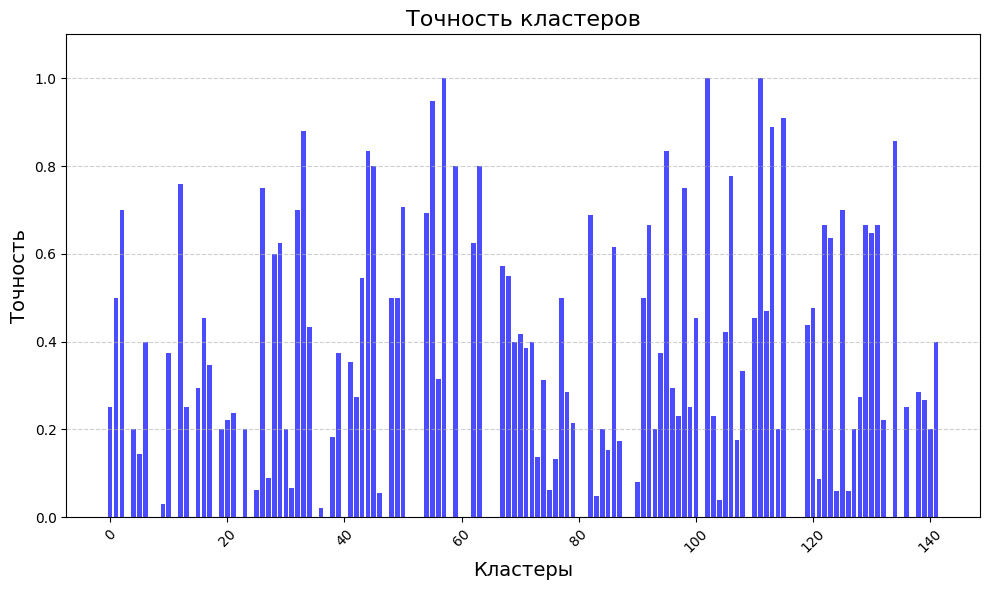

In [ ]:
# @title Выводим точность для каждого кластера из **cluster_stats_united** на диаграмме
clusters = []
accuracies = []
for cluster, stats in cluster_stats_united.items():
    correct = stats['correct']
    total = stats['total']
    accuracy = correct / total if total > 0 else 0
    clusters.append(cluster)
    accuracies.append(accuracy)

# Построение диаграммы
plt.figure(figsize=(10, 6))
plt.bar(clusters, accuracies, color='blue', alpha=0.7)
plt.title('Точность кластеров', fontsize=16)
plt.xlabel('Кластеры', fontsize=14)
plt.ylabel('Точность', fontsize=14)
plt.ylim(0, 1.1)  # Лимит для оси Y
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Вывод графика
plt.tight_layout()
plt.show()

### **Вариант, где вектор — это все вопросы кластера**

В данном блоке кода выполняется несколько ключевых шагов для создания и оценки точности кластеризации вопросов.

1. **Подготовка и индексация данных**:
   - Для каждого кластера создаются документы, состоящие из вопросов и краткого описания (summary). Каждый документ включает метаданные, такие как идентификатор кластера и summary.
   - Создается база данных с использованием индексации вектора, которая хранит векторные представления документов для дальнейшего поиска по схожести (FAISS).
   - Далее рассчитывается количество токенов в документе и определяется стоимость индексации и генерации сводок (summary).

2. **Загрузка и обработка данных**:
   - Загружается CSV файл с вопросами и кластерами, после чего данные сортируются по кластеру.
   
3. **Поиск и оценка точности**:
   - Для каждого вопроса из датафрейма выполняется поиск наиболее похожего документа в базе данных по схожести, используя векторное представление вопроса.
   - Для каждого найденного документа сравнивается его кластер с исходным, и рассчитывается точность классификации для каждого кластера.

4. **Выводы**:
   - В результате выполнения кода выводятся точности кластеризации для каждого кластера. Например, для некоторых кластеров точность может быть 1.00, что означает, что все вопросы из этого кластера были правильно классифицированы. Для других кластеров точность может быть ниже, что указывает на ошибки в классификации.
   - Важно обратить внимание на кластеры с низкой точностью, так как это может указывать на проблемы в качестве векторного представления или неверно подобранные вопросы для этого кластера.

Таким образом, данный код помогает не только создать индексы для быстрого поиска, но и оценить эффективность кластеризации на основе точности классификации вопросов.

In [ ]:
# @title Создаем базу FAISS. Вариант, где вектор - все вопросы кластера
united_chunks = []
count_tokens = 0

for row in df_united_final.itertuples():
  cluster = row.cluster
  questions = row.questions
  summary = row.summary
  united_chunks.append(Document(page_content=questions, metadata={'cluster': cluster, 'summary': summary}))

# Если документ не пуст, то создать и сохранить базу индексов эмбеддингов отрезков документа
if len(united_chunks):
    db_question = FAISS.from_documents(united_chunks, embeddings)
    count_token = num_tokens_from_string(' '.join([x.page_content for x in united_chunks]), "cl100k_base")
    count_tokens += count_token
    print('Количество токенов в документе :', count_token)

    # Сохраняем базу индексов локально в указанную директорию
    save_path = os.path.join(root_path, db_index_path, f"{os.path.splitext(text_file)[0]}_{len_chunk}_summary_large")
    db_question.save_local(save_path)

embed_price = pricing_per_million_tokens_usd.get(model_embed)
print('\nЦЕНА запроса создания базы индексов:', ((int(count_tokens) * embed_price) / 1000000) * usd_price, ' руб.')
print('\nЦЕНА генерации summary:', calculate_total_cost(history_cost))

Количество токенов в документе : 54152

ЦЕНА запроса создания базы индексов: 0.5956720000000001  руб.

ЦЕНА генерации summary: Общая стоимость вызовов для запроса: 0.00000 руб


In [ ]:
# @title Оцениваем точность. Получаем **cluster_stats**

# Вызываем функцию evaluate_accuracy для оценки точности кластеризации.
# Аргументы:
# - df_qw_cluster: Датафрейм, содержащий вопросы и их исходные кластеры.
# - db_question: База данных FAISS, в которой хранятся эмбеддинги для поиска ближайшего соседа.
#
# Функция evaluate_accuracy:
# - Проходит по всем вопросам из df_qw_cluster.
# - Выполняет поиск ближайшего соседа в db_question.
# - Сравнивает исходный кластер вопроса с найденным.
# - Подсчитывает количество совпадений (корректных предсказаний) и общее количество для каждого кластера.
# - Выводит результаты с подсветкой: совпадение или несовпадение кластеров, а также сам вопрос.
#
# Результат:
# - cluster_stats: Словарь, где ключи — кластеры, а значения — статистика с количеством совпадений ('correct') и общим числом вопросов ('total').

cluster_stats = evaluate_accuracy(df_qw_cluster, db_question)

Исходный кластер:   0, Найденный кластер:   0 Вопрос: нужен продвинутый курс
Исходный кластер:   0, Найденный кластер:   0 Вопрос: состав курса базовый
Исходный кластер:   0, Найденный кластер: 116 Вопрос: Что входит в курс на английском
Исходный кластер:   0, Найденный кластер:   0 Вопрос: сколько идёт курс по интеграции в продакшн
Исходный кластер:   0, Найденный кластер:  58 Вопрос: а какие дополнительные курсы есть к этому курсу
Исходный кластер:   0, Найденный кластер:   0 Вопрос: В каком курсе есть про микроконтроллеры и БЛА
Исходный кластер:   0, Найденный кластер:   0 Вопрос: дай краткую информацию про курс интеграции в продакшн
Исходный кластер:   0, Найденный кластер:  72 Вопрос: какие библиотеки мы изучаем на курсе
Исходный кластер:   0, Найденный кластер:   0 Вопрос: как в бизнесе могут помочь знания курса уровень базовый?
Исходный кластер:   0, Найденный кластер:   0 Вопрос: что включает обучение по интеграции в продакшн?
Исходный кластер:   0, Найденный кластер:   0 Вопро

In [ ]:
# @title Сохраняем результат **cluster_stats**
with open(root_path + 'cluster_stats.pickle', 'wb') as f:
    pickle.dump(cluster_stats, f)

In [ ]:
# @title Чекпоинт (загрузка **cluster_stats** из файла)

# Загрузка результата cluster_stats
stats_path = root_path + 'cluster_stats.pickle'
with open(stats_path, 'rb') as f:
    cluster_stats = pickle.load(f)
print(f"Файл cluster_stats загружен: {stats_path}, кластеров: {len(cluster_stats)}")

Файл cluster_stats загружен: /content/local_data/cluster_stats.pickle, кластеров: 142


In [ ]:
# @title Выводим точность для каждого кластера из **cluster_stats**
for cluster, stats in cluster_stats.items():
    correct = stats['correct']
    total = stats['total']
    accuracy = correct / total if total > 0 else 0
    print(f"Кластер: {cluster} - Точность: {accuracy:.2f} ({correct}/{total} верно)")

Кластер: 0 - Точность: 0.54 (15/28 верно)
Кластер: 1 - Точность: 1.00 (2/2 верно)
Кластер: 2 - Точность: 0.90 (9/10 верно)
Кластер: 3 - Точность: 0.86 (6/7 верно)
Кластер: 4 - Точность: 1.00 (5/5 верно)
Кластер: 5 - Точность: 0.33 (7/21 верно)
Кластер: 6 - Точность: 1.00 (5/5 верно)
Кластер: 7 - Точность: 0.86 (12/14 верно)
Кластер: 8 - Точность: 1.00 (5/5 верно)
Кластер: 9 - Точность: 0.59 (20/34 верно)
Кластер: 10 - Точность: 1.00 (16/16 верно)
Кластер: 11 - Точность: 1.00 (4/4 верно)
Кластер: 12 - Точность: 0.88 (22/25 верно)
Кластер: 13 - Точность: 0.46 (22/48 верно)
Кластер: 14 - Точность: 1.00 (6/6 верно)
Кластер: 15 - Точность: 0.76 (13/17 верно)
Кластер: 16 - Точность: 1.00 (11/11 верно)
Кластер: 17 - Точность: 0.81 (21/26 верно)
Кластер: 18 - Точность: 1.00 (9/9 верно)
Кластер: 19 - Точность: 1.00 (15/15 верно)
Кластер: 20 - Точность: 0.81 (22/27 верно)
Кластер: 21 - Точность: 0.52 (11/21 верно)
Кластер: 22 - Точность: 0.93 (13/14 верно)
Кластер: 23 - Точность: 0.50 (10/20 вер

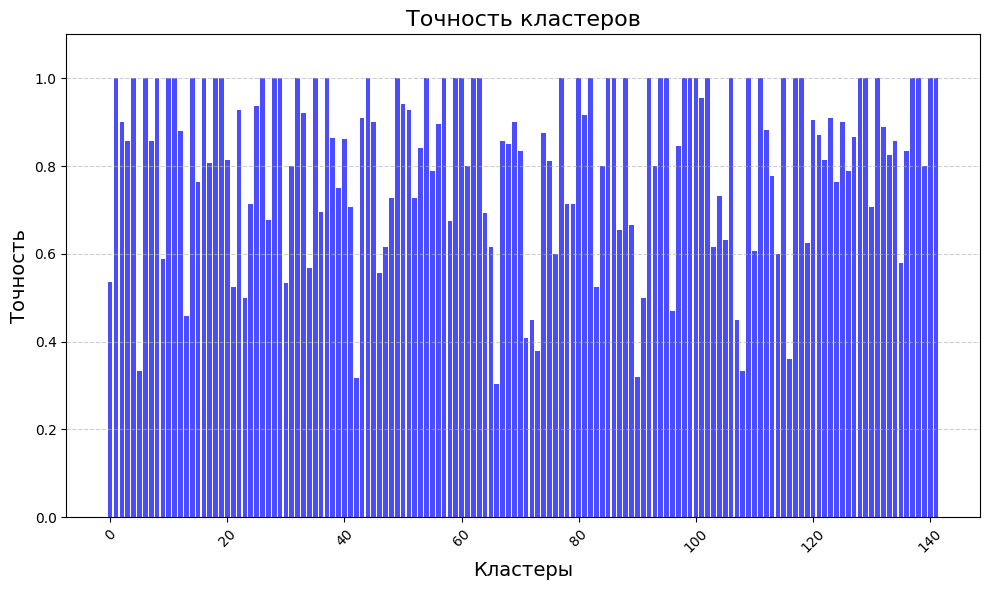

In [ ]:
# @title Выводим точность для каждого кластера из **cluster_stats** на диаграмме
clusters = []
accuracies = []
for cluster, stats in cluster_stats.items():
    correct = stats['correct']
    total = stats['total']
    accuracy = correct / total if total > 0 else 0
    clusters.append(cluster)
    accuracies.append(accuracy)

# Построение диаграммы
plt.figure(figsize=(10, 6))
plt.bar(clusters, accuracies, color='blue', alpha=0.7)
plt.title('Точность кластеров', fontsize=16)
plt.xlabel('Кластеры', fontsize=14)
plt.ylabel('Точность', fontsize=14)
plt.ylim(0, 1.1)  # Лимит для оси Y
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Вывод графика
plt.tight_layout()
plt.show()

### **Вариант, где вектор — это группа рандомная вопросов из кластера**

**Основная цель**

Мы проверяем, насколько точно наша система распределяет вопросы по категориям (кластерам).

**Шаги процесса**

1. **Загрузка и группировка вопросов**
   - **Что делаем**: Загружаем вопросы из файла и распределяем их по категориям.
   - **Зачем**: Чтобы знать, к какой теме относится каждый вопрос и проверить правильность распределения.

2. **Случайное перемешивание вопросов**
   - **Что делаем**: Внутри каждой категории случайно перемешиваем порядок вопросов.
   - **Зачем**: Это помогает системе учиться на разнообразных данных и не зависеть от порядка вопросов.

3. **Создание групп вопросов**
   - **Что делаем**: Объединяем несколько вопросов в одну группу и создаём для них документы с информацией о категории.
   - **Зачем**: Упрощает процесс поиска похожих вопросов и улучшает работу системы.

4. **Создание индекса для поиска**
   - **Что делаем**: Используем FAISS для создания индекса, который позволяет быстро находить похожие группы вопросов.
   - **Зачем**: Чтобы система могла эффективно искать и сравнивать вопросы по их смыслу.

5. **Оценка точности кластеризации**
   - **Что делаем**:
     - Для каждого вопроса ищем 10 похожих групп вопросов.
     - Определяем, какая категория встречается чаще всего среди найденных (не менее 50%).
     - Сравниваем найденную категорию с исходной и считаем, насколько часто система правильно определяет категорию.
   - **Зачем**: Чтобы понять, насколько хорошо система распределяет вопросы по правильным категориям.

6. **Вывод результатов**
   - **Что делаем**: Показываем, насколько точно система классифицирует вопросы для каждой категории.
   - **Зачем**: Оцениваем эффективность системы и выявляем области для улучшения.

**Почему важны случайность и 50% порог**

- **Случайное перемешивание**: Делает обучение системы более надёжным, предотвращая запоминание порядка вопросов и улучшая способность находить настоящие сходства.
  
- **Порог 50%**: Гарантирует, что выбранная категория действительно преобладает среди найденных похожих вопросов, снижая вероятность ошибок и повышая точность классификации.

**Итог**

Этот процесс помогает проверить и улучшить, насколько точно система может распределять вопросы по правильным категориям, делая её более эффективной и надёжной.

In [ ]:
# @title Группируем вопросы случайным образом. Вопросов в группе = 5

import random
from collections import defaultdict

# Задаем размер группы (по сколько вопросов объединять)
group_size = 5  # Изменено с 1 на 5, чтобы избежать индексации отдельных вопросов

# Создаем словарь для хранения вопросов по кластерам
cluster_questions = defaultdict(list)

# Собираем вопросы по кластерам из df_qw_cluster
for row in df_qw_cluster.itertuples():
    query = row.Вопрос
    original_cluster = row.Кластер  # Исправлено с row._2 на row.Кластер
    cluster_questions[original_cluster].append(query)

# Создаем словарь для быстрого доступа к summary по кластерам из df_united_final
# Предполагается, что df_united_final загружен ранее
cluster_summary = {row.cluster: row.summary for row in df_united_final.itertuples()}

# Создаем список для хранения результатов
questions_chunks = []

# Проходим по каждому кластеру и объединяем вопросы в случайные группы
for cluster, questions in cluster_questions.items():
    random.shuffle(questions)  # Перемешиваем вопросы внутри каждого кластера

    # Получаем summary для текущего кластера из df_united_final
    summary = cluster_summary.get(cluster, 'N/A')  # Если summary отсутствует, подставляем 'N/A'

    # Разбиваем на группы по group_size
    for i in range(0, len(questions), group_size):
        # Собираем группу вопросов, с объединением через перенос строки
        question_group = '\n'.join(questions[i:i + group_size])

        # Создаем объект Document с соответствующими метаданными, включая summary
        questions_chunks.append(Document(page_content=question_group,
                                         metadata={'cluster': cluster, 'summary': summary}))

# Теперь в questions_chunks хранятся вопросы, сгруппированные по заданному количеству и кластерам с соответствующим summary

In [ ]:
# @title Создаем базу FAISS (mix=5)

# Если документ не пуст, то создать и сохранить базу индексов эмбеддингов отрезков документа
if len(questions_chunks):
    db_question_mix = FAISS.from_documents(questions_chunks, embeddings)
    count_token = num_tokens_from_string(' '.join([x.page_content for x in questions_chunks]), "cl100k_base")
    count_tokens += count_token
    print('Количество токенов в документе:', count_token)
    db_question_mix.save_local(os.path.join(root_path, db_index_path, f"{os.path.splitext(text_file)[0]}_{len(questions_chunks)}_mix{group_size}_large"))

embed_price = pricing_per_million_tokens_usd.get(model_embed)
print('\nЦЕНА запроса создания базы индексов:', ((int(count_tokens) * embed_price) / 1000000) * usd_price, 'руб.')
print('\nЦЕНА генерации summary:', calculate_total_cost(history_cost))

Количество токенов в документе: 53927

ЦЕНА запроса создания базы индексов: 1.1888690000000002 руб.

ЦЕНА генерации summary: Общая стоимость вызовов для запроса: 0.00000 руб


In [ ]:
# @title Оцениваем точность. Получаем **cluster_stats_mix**

# Вызываем функцию evaluate_accuracy для оценки точности кластеризации.
# Аргументы:
# - df_qw_cluster: Датафрейм, содержащий вопросы и их исходные кластеры.
# - db_question_mix: База данных FAISS, в которой хранятся эмбеддинги для поиска ближайшего соседа.
#
# Функция evaluate_accuracy:
# - Проходит по всем вопросам из df_qw_cluster.
# - Выполняет поиск ближайшего соседа в db_question_mix.
# - Сравнивает исходный кластер вопроса с найденным.
# - Подсчитывает количество совпадений (корректных предсказаний) и общее количество для каждого кластера.
# - Выводит результаты с подсветкой: совпадение или несовпадение кластеров, а также сам вопрос.
#
# Результат:
# - cluster_stats_mix: Словарь, где ключи — кластеры, а значения — статистика с количеством совпадений ('correct') и общим числом вопросов ('total').

cluster_stats_mix = evaluate_accuracy(df_qw_cluster, db_question_mix)

Исходный кластер:   0, Найденный кластер:   0 Вопрос: нужен продвинутый курс
Исходный кластер:   0, Найденный кластер:  58 Вопрос: состав курса базовый
Исходный кластер:   0, Найденный кластер:   0 Вопрос: Что входит в курс на английском
Исходный кластер:   0, Найденный кластер:   0 Вопрос: сколько идёт курс по интеграции в продакшн
Исходный кластер:   0, Найденный кластер: 123 Вопрос: а какие дополнительные курсы есть к этому курсу
Исходный кластер:   0, Найденный кластер:   0 Вопрос: В каком курсе есть про микроконтроллеры и БЛА
Исходный кластер:   0, Найденный кластер:   0 Вопрос: дай краткую информацию про курс интеграции в продакшн
Исходный кластер:   0, Найденный кластер:   0 Вопрос: какие библиотеки мы изучаем на курсе
Исходный кластер:   0, Найденный кластер:  29 Вопрос: как в бизнесе могут помочь знания курса уровень базовый?
Исходный кластер:   0, Найденный кластер:   0 Вопрос: что включает обучение по интеграции в продакшн?
Исходный кластер:   0, Найденный кластер:   0 Вопро

In [ ]:
# @title Сохраняем результат **cluster_stats_mix**
with open(root_path + 'cluster_stats_mix.pickle', 'wb') as f:
    pickle.dump(cluster_stats_mix, f)

In [ ]:
# @title Чекпоинт (загрузка **cluster_stats_mix** из файла)

# Загрузка результата cluster_stats_mix
mix_stats_path = root_path + 'cluster_stats_mix.pickle'
with open(mix_stats_path, 'rb') as f:
    cluster_stats_mix = pickle.load(f)
print(f"Файл cluster_stats_mix загружен: {mix_stats_path}, кластеров: {len(cluster_stats_mix)}")

Файл cluster_stats_mix загружен: /content/local_data/cluster_stats_mix.pickle, кластеров: 142


In [ ]:
# @title Выводим точность для каждого кластера из **cluster_stats_mix**
for cluster, stats in cluster_stats_mix.items():
    correct = stats['correct']
    total = stats['total']
    accuracy = correct / total if total > 0 else 0
    print(f"Кластер: {cluster} - Точность: {accuracy:.2f} ({correct}/{total} верно)")

Кластер: 0 - Точность: 0.79 (22/28 верно)
Кластер: 1 - Точность: 1.00 (2/2 верно)
Кластер: 2 - Точность: 0.80 (8/10 верно)
Кластер: 3 - Точность: 1.00 (7/7 верно)
Кластер: 4 - Точность: 1.00 (5/5 верно)
Кластер: 5 - Точность: 0.81 (17/21 верно)
Кластер: 6 - Точность: 1.00 (5/5 верно)
Кластер: 7 - Точность: 0.93 (13/14 верно)
Кластер: 8 - Точность: 1.00 (5/5 верно)
Кластер: 9 - Точность: 0.82 (28/34 верно)
Кластер: 10 - Точность: 1.00 (16/16 верно)
Кластер: 11 - Точность: 1.00 (4/4 верно)
Кластер: 12 - Точность: 1.00 (25/25 верно)
Кластер: 13 - Точность: 0.88 (42/48 верно)
Кластер: 14 - Точность: 0.83 (5/6 верно)
Кластер: 15 - Точность: 0.94 (16/17 верно)
Кластер: 16 - Точность: 1.00 (11/11 верно)
Кластер: 17 - Точность: 0.92 (24/26 верно)
Кластер: 18 - Точность: 1.00 (9/9 верно)
Кластер: 19 - Точность: 0.60 (9/15 верно)
Кластер: 20 - Точность: 0.89 (24/27 верно)
Кластер: 21 - Точность: 0.76 (16/21 верно)
Кластер: 22 - Точность: 1.00 (14/14 верно)
Кластер: 23 - Точность: 0.95 (19/20 вер

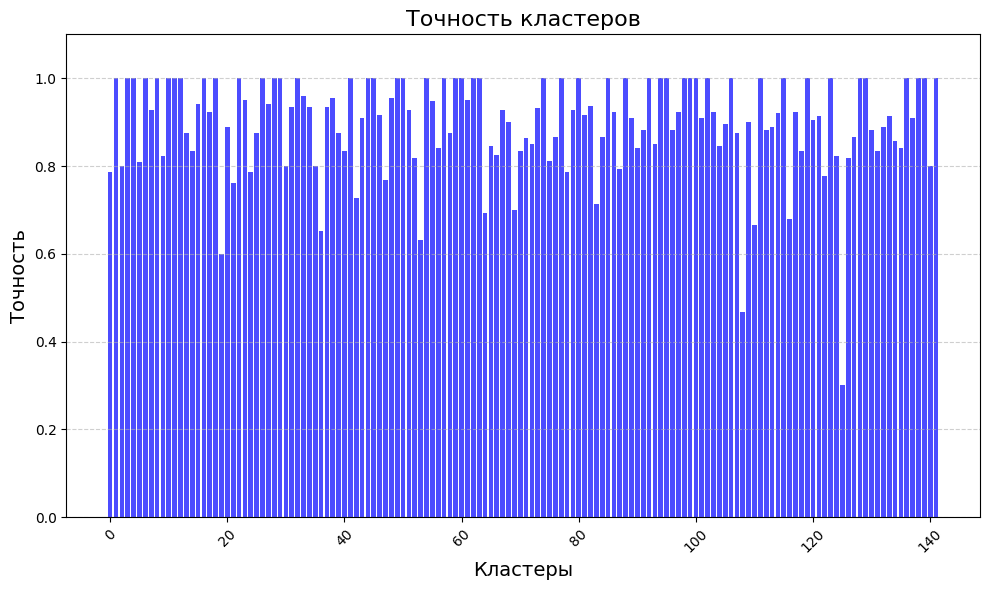

In [ ]:
# @title Выводим точность для каждого кластера из **cluster_stats_mix** на диаграмме
clusters = []
accuracies = []
for cluster, stats in cluster_stats_mix.items():
    correct = stats['correct']
    total = stats['total']
    accuracy = correct / total if total > 0 else 0
    clusters.append(cluster)
    accuracies.append(accuracy)

# Построение диаграммы
plt.figure(figsize=(10, 6))
plt.bar(clusters, accuracies, color='blue', alpha=0.7)
plt.title('Точность кластеров', fontsize=16)
plt.xlabel('Кластеры', fontsize=14)
plt.ylabel('Точность', fontsize=14)
plt.ylim(0, 1.1)  # Лимит для оси Y
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Вывод графика
plt.tight_layout()
plt.show()

### **Подсчет статистики чанков по преобладающему 50% кластеру среди 10 найденных**

В данном исследовании проводится анализ качества кластеризации на основе правила **50% попаданий**. Это означает, что кластер для вопроса считается правильно определённым, если более половины (≥50%) найденных ближайших соседей принадлежат одному и тому же кластеру.

#### Цели анализа:
1. **Оценить точность кластеризации:** Проверить, насколько часто найденный кластер совпадает с исходным при условии 50% попаданий.
2. **Выявить проблемные кластеры:** Определить кластеры с низкой точностью, чтобы улучшить алгоритм или данные.
3. **Сравнить распределение точности:** Понять, как точность варьируется между разными кластерами.

#### Подход:
1. Для каждого вопроса выполняется поиск по 10 наиболее похожим документам.
2. Подсчитывается, сколько раз каждый кластер встречается среди найденных.
3. Кластер с максимальной частотой считается определённым, если он встречается не менее 5 раз (50% от 10).
4. Вычисляется точность для каждого исходного кластера, сравнивая найденные и исходные значения.

Этот анализ позволяет глубже понять, как эффективно модель работает с разными кластерами, и выявить направления для улучшения.

In [ ]:
# @title Оценка точности по 50% попаданий

import pandas as pd
from collections import defaultdict, Counter

# Для хранения статистики по каждому кластеру
cluster_stats_50 = defaultdict(lambda: {'correct': 0, 'total': 0})

# Проходим по каждой строке датафрейма
for row in df_qw_cluster.itertuples():
    query = row.Вопрос
    original_cluster = row.Кластер  # Это ваш исходный кластер

    # Выполняем поиск по 10 наиболее похожим чанкам
    docs = db_question_mix.similarity_search(query, k=10)

    # Собираем кластеры найденных чанков, проверяя наличие 'cluster' в метаданных
    found_clusters = []
    for doc in docs:
        if 'cluster' in doc.metadata:
            found_clusters.append(doc.metadata['cluster'])
        else:
            found_clusters.append(None)  # Если 'cluster' нет, добавляем None

    # Подсчитываем количество каждого кластера среди найденных чанков
    cluster_count = Counter(found_clusters)

    # Логирование для диагностики
    print(f"Вопрос: {query}")
    print(f"Найденные кластеры: {cluster_count}")

    # Определяем кластер с максимальной частотой
    most_common_cluster, count = cluster_count.most_common(1)[0]

    # Если кластер встречается хотя бы 50% раз (5 из 10), то он считается найденным
    if count >= 5:
        found_cluster = most_common_cluster
    else:
        # Возвращаем кластер с максимальной частотой, даже если он не набрал 50%
        # found_cluster = most_common_cluster

        # Возвращаем None
        found_cluster = None

    # Увеличиваем счетчик общего количества для данного исходного кластера
    cluster_stats_50[original_cluster]['total'] += 1

    # Сравниваем найденный кластер с исходным
    if found_cluster == original_cluster:
        cluster_stats_50[original_cluster]['correct'] += 1

    # Выводим текущие результаты
    print(f"Исходный кластер: {original_cluster}, Найденный кластер: {found_cluster}\n")

Выходные данные были обрезаны до нескольких последних строк (5000).
Вопрос: клиент хочет ассистента своего на основе чата гпт, но  не в openai держать, потому что NDA
Найденные кластеры: Counter({36: 4, 66: 2, 73: 2, 4: 1, 104: 1})
Исходный кластер: 66, Найденный кластер: None

Вопрос: Окей. На вашем сайте есть AI-консультант?
Найденные кластеры: Counter({66: 3, 20: 3, 124: 1, 17: 1, 56: 1, 121: 1})
Исходный кластер: 66, Найденный кластер: None

Вопрос: Можно ли создать нейросотрудника на базе гигачата
Найденные кластеры: Counter({66: 3, 46: 2, 13: 2, 124: 1, 127: 1, 39: 1})
Исходный кластер: 66, Найденный кластер: None

Вопрос: можно ли создать нейро-сотрудника, который будет переводить текст в презентацию с фото?
Найденные кластеры: Counter({66: 3, 46: 2, 39: 2, 124: 1, 127: 1, 92: 1})
Исходный кластер: 66, Найденный кластер: None

Вопрос: можно ли создать прототип приложения с помощью ИИ?
Найденные кластеры: Counter({105: 4, 66: 2, 20: 2, 79: 1, 133: 1})
Исходный кластер: 66, Найден

In [ ]:
# @title Сохраняем результат **cluster_stats_50**
import pickle

# Преобразуем defaultdict в обычный словарь перед сохранением
cluster_stats_50_dict = dict(cluster_stats_50)

with open(root_path + 'cluster_stats_50.pickle', 'wb') as f:
    pickle.dump(cluster_stats_50_dict, f)
print("Результат cluster_stats_50 сохранён как словарь")

Результат cluster_stats_50 сохранён как словарь


In [ ]:
# @title Чекпоинт (загрузка **cluster_stats_50** из файла)
from collections import defaultdict

with open(root_path + 'cluster_stats_50.pickle', 'rb') as f:
    cluster_stats_50_dict = pickle.load(f)
    cluster_stats_50 = defaultdict(lambda: {'correct': 0, 'total': 0}, cluster_stats_50_dict)
print(f"Файл cluster_stats_50 загружен: кластеров: {len(cluster_stats_50)}")

Файл cluster_stats_50 загружен: кластеров: 142


In [ ]:
# @title Рассчитываем точность для каждого кластера
for cluster, stats in cluster_stats_50.items():
    correct = stats['correct']
    total = stats['total']
    accuracy = correct / total if total > 0 else 0
    print(f"Кластер: {cluster} - Точность: {accuracy:.2f} ({correct}/{total} верно)")

Кластер: 0 - Точность: 0.14 (4/28 верно)
Кластер: 1 - Точность: 0.00 (0/2 верно)
Кластер: 2 - Точность: 0.00 (0/10 верно)
Кластер: 3 - Точность: 0.00 (0/7 верно)
Кластер: 4 - Точность: 0.00 (0/5 верно)
Кластер: 5 - Точность: 0.00 (0/21 верно)
Кластер: 6 - Точность: 0.00 (0/5 верно)
Кластер: 7 - Точность: 0.00 (0/14 верно)
Кластер: 8 - Точность: 0.00 (0/5 верно)
Кластер: 9 - Точность: 0.26 (9/34 верно)
Кластер: 10 - Точность: 0.00 (0/16 верно)
Кластер: 11 - Точность: 0.00 (0/4 верно)
Кластер: 12 - Точность: 0.36 (9/25 верно)
Кластер: 13 - Точность: 0.50 (24/48 верно)
Кластер: 14 - Точность: 0.00 (0/6 верно)
Кластер: 15 - Точность: 0.00 (0/17 верно)
Кластер: 16 - Точность: 0.00 (0/11 верно)
Кластер: 17 - Точность: 0.58 (15/26 верно)
Кластер: 18 - Точность: 0.00 (0/9 верно)
Кластер: 19 - Точность: 0.00 (0/15 верно)
Кластер: 20 - Точность: 0.15 (4/27 верно)
Кластер: 21 - Точность: 0.14 (3/21 верно)
Кластер: 22 - Точность: 0.00 (0/14 верно)
Кластер: 23 - Точность: 0.00 (0/20 верно)
Кластер:

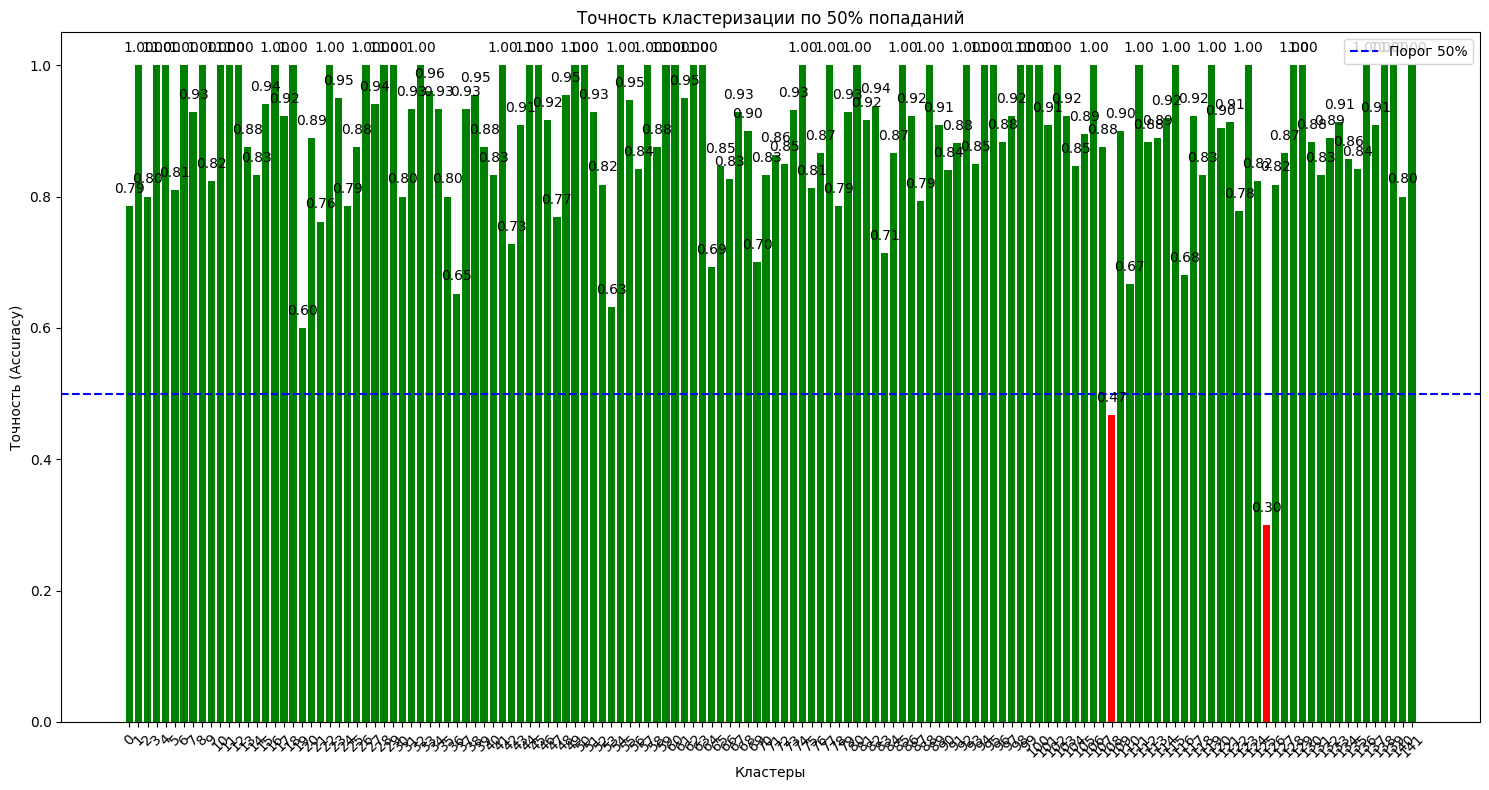

In [ ]:
# @title Построение графика
plt.figure(figsize=(15, 8))
bars = plt.bar(clusters, accuracies, color=['green' if acc >= 0.5 else 'red' for acc in accuracies])

# Добавление подписей
plt.xlabel('Кластеры')
plt.ylabel('Точность (Accuracy)')
plt.title('Точность кластеризации по 50% попаданий')
plt.axhline(y=0.5, color='blue', linestyle='--', label='Порог 50%')

# Отображение меток для каждого кластера
plt.xticks(clusters, rotation=45)

# Вывод значений над столбцами
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02, f'{acc:.2f}', ha='center')

plt.legend()
plt.tight_layout()
plt.show()


### **Подсчет статистики чанков по преобладающему в принципе кластеру среди 10 найденных**

В этом исследовании анализируется точность кластеризации без применения правила **50% попаданий**. Вместо этого для определения кластера используется наиболее часто встречающийся кластер среди найденных ближайших соседей, независимо от его частоты.

#### Цели анализа:
1. **Проверить точность кластеризации:** Оценить, насколько корректно определяется кластер для вопроса, если учитывать только самый частотный кластер.
2. **Сравнить с результатами 50% попаданий:** Определить, насколько точность изменяется при отказе от порогового правила.
3. **Выявить отклонения:** Обнаружить кластеры, где часто возникают ошибки, даже при использовании упрощённого подхода.

#### Подход:
1. Для каждого вопроса выполняется поиск по 10 наиболее похожим документам.
2. Среди найденных документов определяется кластер с максимальной частотой (без проверки 50% порога).
3. Вычисляется точность, сравнивая найденный кластер с исходным для каждого вопроса.
4. Формируется статистика по точности для каждого кластера.

#### Отличие от предыдущего подхода:
- В данном методе отсутствует пороговое правило, что позволяет учесть даже те случаи, когда "правильный" кластер встречается менее 50% раз.
- Это может дать большее число совпадений, но также увеличивает вероятность ложных классификаций.

#### Выводы:
Данный подход позволяет оценить, как часто кластеризация работает корректно без дополнительных ограничений. Сравнение результатов с пороговым правилом 50% попаданий поможет понять, насколько значимым было это ограничение в анализе.

In [ ]:
# @title Оценка точности без учета 50% попаданий

import pandas as pd
from collections import defaultdict, Counter

# Для хранения статистики по каждому кластеру
cluster_stats_free = defaultdict(lambda: {'correct': 0, 'total': 0})

# Проходим по каждой строке датафрейма
for row in df_qw_cluster.itertuples():
    query = row.Вопрос
    original_cluster = row.Кластер  # Это ваш исходный кластер

    # Выполняем поиск по 10 наиболее похожим чанкам
    docs = db_question_mix.similarity_search(query, k=10)

    # Собираем кластеры найденных чанков, проверяя наличие 'cluster' в метаданных
    found_clusters = []
    for doc in docs:
        if 'cluster' in doc.metadata:
            found_clusters.append(doc.metadata['cluster'])
        else:
            found_clusters.append(None)  # Если 'cluster' нет, добавляем None

    # Подсчитываем количество каждого кластера среди найденных чанков
    cluster_count = Counter(found_clusters)

    # Логирование для диагностики
    print(f"Вопрос: {query}")
    print(f"Найденные кластеры: {cluster_count}")

    # Определяем кластер с максимальной частотой
    most_common_cluster, count = cluster_count.most_common(1)[0]

    # Если кластер встречается хотя бы 50% раз (5 из 10), то он считается найденным
    if count >= 5:
        found_cluster = most_common_cluster
    else:
        # Возвращаем кластер с максимальной частотой, даже если он не набрал 50%
        found_cluster = most_common_cluster

        # Возвращаем None
        # found_cluster = None

    # Увеличиваем счетчик общего количества для данного исходного кластера
    cluster_stats_free[original_cluster]['total'] += 1

    # Сравниваем найденный кластер с исходным
    if found_cluster == original_cluster:
        cluster_stats_free[original_cluster]['correct'] += 1

    # Выводим текущие результаты
    print(f"Исходный кластер: {original_cluster}, Найденный кластер: {found_cluster}\n")

Выходные данные были обрезаны до нескольких последних строк (5000).
Вопрос: клиент хочет ассистента своего на основе чата гпт, но  не в openai держать, потому что NDA
Найденные кластеры: Counter({36: 4, 66: 2, 73: 2, 4: 1, 104: 1})
Исходный кластер: 66, Найденный кластер: 36

Вопрос: Окей. На вашем сайте есть AI-консультант?
Найденные кластеры: Counter({66: 3, 20: 3, 124: 1, 17: 1, 56: 1, 121: 1})
Исходный кластер: 66, Найденный кластер: 66

Вопрос: Можно ли создать нейросотрудника на базе гигачата
Найденные кластеры: Counter({66: 3, 46: 2, 13: 2, 124: 1, 127: 1, 39: 1})
Исходный кластер: 66, Найденный кластер: 66

Вопрос: можно ли создать нейро-сотрудника, который будет переводить текст в презентацию с фото?
Найденные кластеры: Counter({66: 3, 46: 2, 39: 2, 124: 1, 127: 1, 92: 1})
Исходный кластер: 66, Найденный кластер: 66

Вопрос: можно ли создать прототип приложения с помощью ИИ?
Найденные кластеры: Counter({105: 4, 66: 2, 20: 2, 79: 1, 133: 1})
Исходный кластер: 66, Найденный клас

In [ ]:
# @title Сохраняем результат **cluster_stats_free**
import pickle

# Преобразуем defaultdict в обычный словарь перед сохранением
cluster_stats_free_dict = dict(cluster_stats_free)

with open(root_path + 'cluster_stats_free.pickle', 'wb') as f:
    pickle.dump(cluster_stats_free_dict, f)
print("Результат cluster_stats_free сохранён как словарь")

Результат cluster_stats_free сохранён как словарь


In [ ]:
# @title Чекпоинт (загрузка **cluster_stats_free** из файла)
from collections import defaultdict

with open(root_path + 'cluster_stats_free.pickle', 'rb') as f:
    cluster_stats_free_dict = pickle.load(f)
    cluster_stats_free = defaultdict(lambda: {'correct': 0, 'total': 0}, cluster_stats_free_dict)
print(f"Файл cluster_stats_free загружен: кластеров: {len(cluster_stats_free)}")

Файл cluster_stats_free загружен: кластеров: 142


In [ ]:
# @title Рассчитываем точность для каждого кластера
for cluster, stats in cluster_stats_free.items():
    correct = stats['correct']
    total = stats['total']
    accuracy = correct / total if total > 0 else 0
    print(f"Кластер: {cluster} - Точность: {accuracy:.2f} ({correct}/{total} верно)")

Кластер: 0 - Точность: 0.61 (17/28 верно)
Кластер: 1 - Точность: 0.00 (0/2 верно)
Кластер: 2 - Точность: 0.20 (2/10 верно)
Кластер: 3 - Точность: 0.57 (4/7 верно)
Кластер: 4 - Точность: 0.00 (0/5 верно)
Кластер: 5 - Точность: 0.38 (8/21 верно)
Кластер: 6 - Точность: 0.00 (0/5 верно)
Кластер: 7 - Точность: 0.93 (13/14 верно)
Кластер: 8 - Точность: 0.00 (0/5 верно)
Кластер: 9 - Точность: 0.82 (28/34 верно)
Кластер: 10 - Точность: 1.00 (16/16 верно)
Кластер: 11 - Точность: 0.00 (0/4 верно)
Кластер: 12 - Точность: 0.84 (21/25 верно)
Кластер: 13 - Точность: 0.77 (37/48 верно)
Кластер: 14 - Точность: 0.17 (1/6 верно)
Кластер: 15 - Точность: 0.65 (11/17 верно)
Кластер: 16 - Точность: 0.82 (9/11 верно)
Кластер: 17 - Точность: 0.88 (23/26 верно)
Кластер: 18 - Точность: 0.33 (3/9 верно)
Кластер: 19 - Точность: 0.20 (3/15 верно)
Кластер: 20 - Точность: 0.59 (16/27 верно)
Кластер: 21 - Точность: 0.52 (11/21 верно)
Кластер: 22 - Точность: 0.50 (7/14 верно)
Кластер: 23 - Точность: 0.90 (18/20 верно)

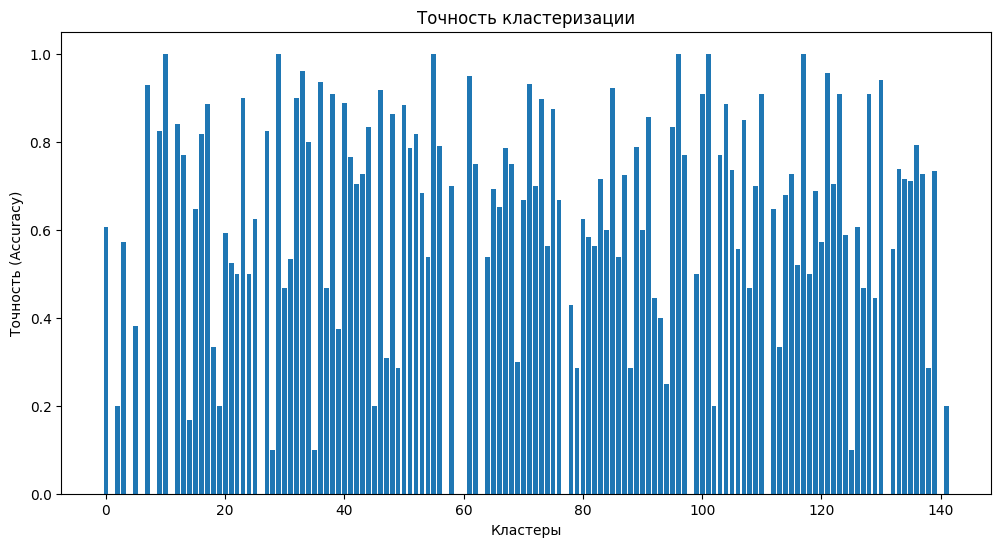

In [ ]:
# @title Построение графика

import matplotlib.pyplot as plt

# Данные для графика
clusters = []
accuracies = []

# Заполняем данные из cluster_stats_free
for cluster, stats in cluster_stats_free.items():
    correct = stats['correct']
    total = stats['total']
    accuracy = correct / total if total > 0 else 0
    clusters.append(cluster)
    accuracies.append(accuracy)

# Построение графика
plt.figure(figsize=(12, 6))
plt.bar(clusters, accuracies)

# Подписи осей и заголовок
plt.xlabel('Кластеры')
plt.ylabel('Точность (Accuracy)')
plt.title('Точность кластеризации')

# Показать график
plt.show()
